# Section 4.4

## Example 4.4.1

In [ ]:
using Plots, LaTeXStrings
theme(:dark)

f(x) = x * exp(x) - 2;
plot(f, 0.25, 1.25; label="function",  legend=:topleft, xlabel=L"x",  ylabel=L"y")

In [ ]:
x₁ = 1;     y₁ = f(x₁);
x₂ = 0.5;   y₂ = f(x₂);
scatter!([x₁, x₂], [y₁, y₂]; label="initial points")

In [ ]:
m₂ = (y₂ - y₁) / (x₂ - x₁)
secant(x) = y₂ + m₂ * (x - x₂)
plot!(secant, 0.25, 1.25; label="secant line", l=:dash, color=:white)

In [ ]:
x₃ = x₂ - y₂ / m₂
y₃ = f(x₃)

In [ ]:
scatter!([x₃], [0], label="root of secant")

In [ ]:
plot(f, 0.25, 1.25; label="function",  legend=:topleft, xlabel=L"x",  ylabel=L"y")
scatter!([x₂, x₃], [y₂, y₃]; label="initial points")

m₃ = (y₃ - y₂) / (x₃ - x₂)
secant(x) = y₃ + m₃ * (x - x₃)
plot!(secant, 0.25, 1.25; label="secant line", l=:dash, color=:white)

In [ ]:
x₄ = x₃ - y₃ / m₃

## Example 4.4.2

In [ ]:
using FNCFunctions

f(x) = x * exp(x) - 2
x = FNC.secant(f, BigFloat(1), BigFloat(0.5), xtol=1e-80, ftol=1e-80);

In [ ]:
r = x[end]

In [ ]:
ϵ = @. Float64(r - x[1:end-1])

In [ ]:
using PrettyTables

logerr = @. log10(abs(ϵ))
ratios = [NaN; [logerr[i+1] / logerr[i] for i in 1:length(logerr)-1]]
pretty_table( (iter=eachindex(ϵ), ϵ, logerr, ratios);
    column_labels=["iteration", "error", "log error", "ratio"], backend=:html )

## Example 4.4.3

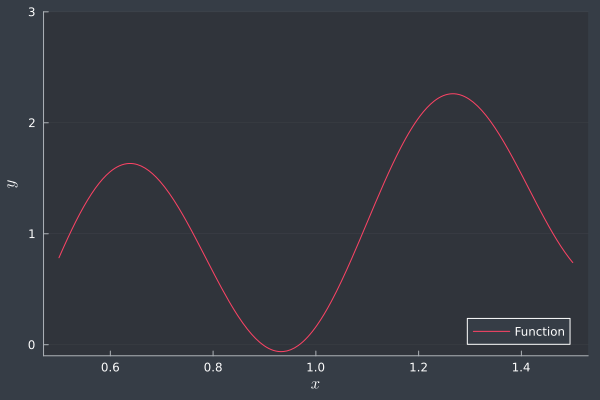

In [15]:
using Plots, LaTeXStrings
theme(:dark)

f(x) = x + cos(10 * x)
interval = [0.5, 1.5]

plot(f, interval..., label="Function", legend=:bottomright,
    grid=:y, ylim=[-0.1, 3], xlabel=L"x", ylabel=L"y")

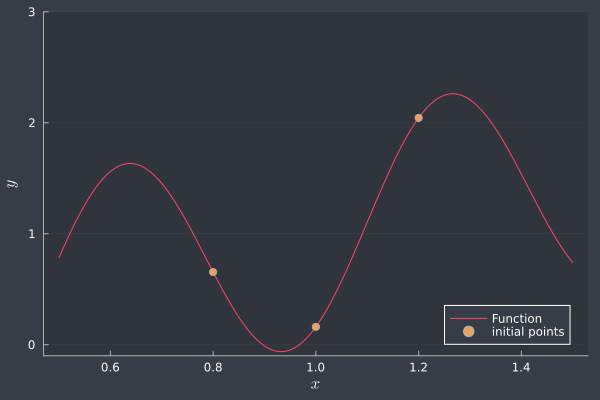

In [16]:
x = [0.8, 1.2, 1]
y = @. f(x)
scatter!(x, y, label="initial points")

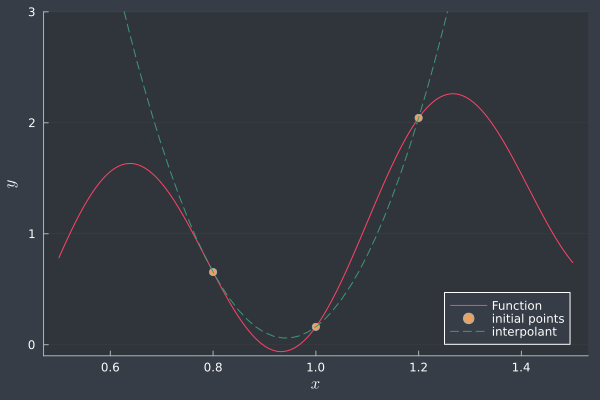

In [17]:
using Polynomials
q = Polynomials.fit(x, y, 2)      # interpolating polynomial
plot!(x -> q(x), interval..., l=:dash, label="interpolant")

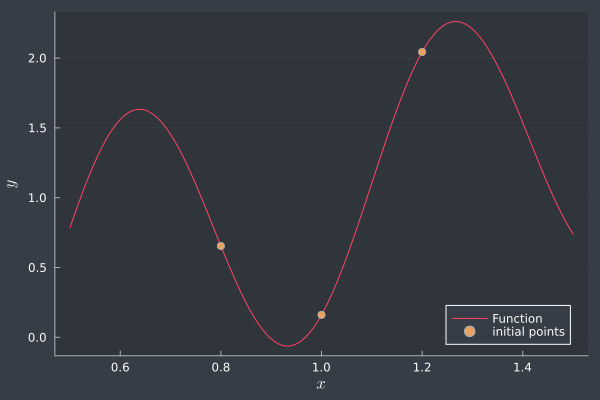

In [18]:
plot(f, interval..., label="Function",
    legend=:bottomright, grid=:y, xlabel=L"x", ylabel=L"y")
scatter!(x, y, label="initial points")

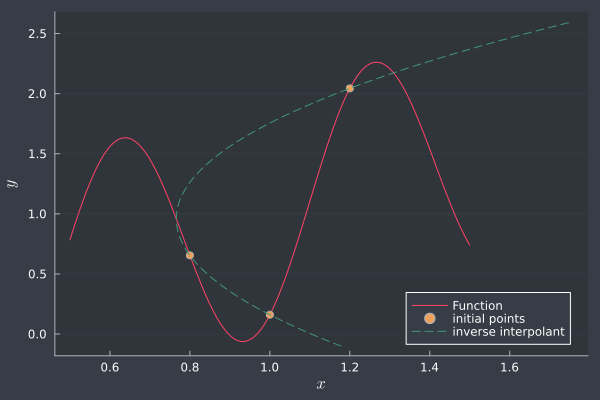

In [19]:
q = Polynomials.fit(y, x, 2)       # interpolating polynomial
plot!(y -> q(y), y -> y, -0.1, 2.6, l=:dash, label="inverse interpolant")

In [20]:
q(0)

1.1039813854404716

In [22]:
x = BigFloat.([8, 12, 10]) / 10
y = @. f(x)

for k = 3:12
    q = Polynomials.fit(y[k-2:k], x[k-2:k], 2)
    push!(x, q(0))
    push!(y, f(x[k+1]))
end

residual = f(x[end])

0.0

In [23]:
using PrettyTables

r = x[end]
ϵ = @. Float64(abs(r - x[1:end-1]))
logerr = @. log10(abs(ϵ))
ratios = [NaN; [logerr[i+1] / logerr[i] for i in 1:length(logerr)-1]]
pretty_table( (iter=eachindex(ϵ), ϵ, logerr, ratios);
    column_labels=["iteration", "error", "log error", "ratio"], backend=:html )

iteration,error,log error,ratio
1,0.167888,-0.774979,NaN
2,0.232112,-0.634303,0.818478
3,0.0321116,-1.49334,2.3543
4,0.136093,-0.866164,0.580019
5,0.0153473,-1.81397,2.09425
6,0.00326831,-2.48568,1.3703
7,0.000461744,-3.3356,1.34193
8,6.29585e-6,-5.20095,1.55922
9,3.43898e-9,-8.46357,1.62731
10,3.87305e-15,-14.4119,1.70282
